# 5차시 실습 — 시각 검색 시스템 (Visual Search System)

**인공지능 플랫폼 설계 및 실습** · *이미지를 벡터로, 벡터를 가까운 순으로*

---
이 노트북은 강의(교안) **§0 ~ §6** 에 대응하는 **다섯 개의 실습**으로 이루어집니다.
각 실습은 앞 실습의 결과를 이어받으므로 **위에서부터 순서대로** 실행하세요.

| 실습 | 내용 | 대응 강의  |
|---|---|---|
| 실습 1 | 픽셀·채널·커널 — 이미지를 배열로 다루기 | §0 (슬라이드 8~13)  |
| 실습 2 | 사전학습 임베딩으로 유사 이미지 찾기 | §0·§3 (슬라이드 16·31) |
| 실습 3 | 대조학습으로 임베딩 다시 배우기 | §4 (슬라이드 34~40) |
| 실습 4 | nDCG로 채점하기 | §5 (슬라이드 42~45)  |
| 실습 5 | ANN(근사 탐색)과 재랭킹 | §6 (슬라이드 47~52) |

> **실행 환경** · Google Colab 또는 로컬 Jupyter · **GPU 없이 CPU로 완주**할 수 있습니다.
> 데이터셋은 **CIFAR-10**(6만 장, 32×32 컬러)이며 처음 한 번 자동으로 내려받습니다.

---
## ✍️ 학생용 안내 — 이렇게 진행하세요
- 곳곳에 **`# TODO`** 로 표시된 **빈칸(`____`)** 이 있습니다. 그 **바로 위 설명과 힌트**를 읽고 `____`를 채우면 됩니다. (대개 1~3줄)
- 빈칸이 아닌 코드는 **그대로 실행**하면 됩니다. (그림 그리기·데이터 준비 등은 이미 채워져 있습니다.)
- 각 실습 끝의 **✅ 확인 질문/제출물**에 여러분의 답을 적어 제출하세요.
- 막히면: 힌트를 다시 읽고 → 그래도 안 되면 조교/교수자에게 질문하세요. 정답을 외우는 것보다 **왜 그렇게 되는지** 이해하는 것이 목표입니다.

> **채워야 할 핵심 6곳**: ① 픽셀 거리 ② 합성곱 ③ 유사도 검색 ④ 관련성 점수 ⑤ nDCG ⑥ 근사탐색(ANN)·재랭킹.
> 이 여섯 가지가 "이미지를 벡터로, 벡터를 가까운 순으로"의 전부입니다.

## 0. 준비 — 라이브러리 · 한글 폰트 · 데이터
아래 세 셀을 **가장 먼저** 실행하세요. CIFAR-10 다운로드가 처음 한 번 시간이 걸립니다. (여기는 채울 것이 없습니다.)

In [1]:
import os, time
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')   # 텐서플로 로그 줄이기

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 재현성: 학습에 쓰이는 무작위(가중치 초기화·증강)를 고정한다
tf.keras.utils.set_random_seed(42)

print('TensorFlow', tf.__version__)
print('GPU 사용 가능:', bool(tf.config.list_physical_devices('GPU')), '(없어도 됩니다)')

TensorFlow 2.21.0
GPU 사용 가능: False (없어도 됩니다)


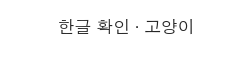

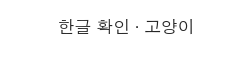

In [24]:
# ============================================================
# 0. 환경 설정 (Colab 에서 런타임을 다시 연결할 때마다 실행)
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    if not any('Nanum' in f.name for f in matplotlib.font_manager.fontManager.ttflist):
        os.system('apt-get -qq install -y fonts-nanum > /dev/null 2>&1')
        matplotlib.font_manager._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'
except Exception:
    pass


import matplotlib.font_manager as fm, os, subprocess

def setup_korean_font():
    path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
    if not os.path.exists(path):
        try:
            subprocess.run(["apt-get", "install", "-y", "fonts-nanum"],
                           check=False, capture_output=True)
        except Exception:
            pass
    if os.path.exists(path):
        fm.fontManager.addfont(path)
        plt.rcParams["font.family"] = "NanumBarunGothic"
    plt.rc("axes", unicode_minus=False)

setup_korean_font()
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0]
              if isinstance(plt.rcParams["font.family"], list) else plt.rcParams["font.family"])
plt.rc("axes", unicode_minus=False)
# 맥북 한글 폰트 설정
plt.rcParams["font.family"] = "AppleGothic"
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(3,0.6)); plt.text(0.5,0.5,'한글 확인 · 고양이', ha='center'); plt.axis('off'); plt.show()
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(3,0.6)); plt.text(0.5,0.5,'한글 확인 · 고양이', ha='center'); plt.axis('off'); plt.show()

In [3]:
# CIFAR-10 불러오기 (처음 한 번 자동 다운로드)
(_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_test = y_test.ravel()
CLASS = ['비행기','자동차','새','고양이','사슴','개','개구리','말','배','트럭']

# ── 검색 대상 DB와 질의를 '고정 인덱스'로 정한다 (랜덤 추출 없음) ──
X_db  = x_test[:2000]          # 검색 대상 = 우리 서비스에 저장된 이미지 2000장
y_db  = y_test[:2000]
QUERIES = [7, 12, 25, 44]      # 항상 이 4장을 질의로 쓴다 (누가 실행해도 동일)

print('검색 DB :', X_db.shape, '· 질의 인덱스 :', QUERIES)
for q in QUERIES:
    print(f'  질의 {q:>3d} → {CLASS[y_db[q]]}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3390s 20us/step
검색 DB : (2000, 32, 32, 3) · 질의 인덱스 : [7, 12, 25, 44]
  질의   7 → 개구리
  질의  12 → 개
  질의  25 → 새
  질의  44 → 비행기


---
# 실습 1 — 픽셀·채널·커널

> **강의 대응** §0 슬라이드 8~13
> **목표** 이미지가 (H, W, C) 숫자 배열임을 눈으로 확인하고, 픽셀 거리의 한계를 직접 재고, 커널(필터)이 특성맵을 만드는 과정을 손으로 구현한다.

### 1-1. 이미지를 배열로 열기 — 컴퓨터는 무엇을 보는가  *(슬라이드 8)*  · (실행만)

shape : (32, 32, 3)   ← (H, W, C) = (높이, 너비, 채널)
dtype : uint8 · 최솟값/최댓값 : 9 / 255
숫자 개수 : 3072 개  (= 32 × 32 × 3)


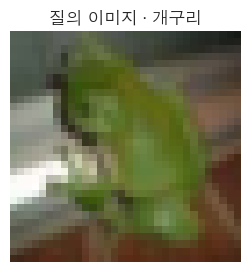

In [25]:
img = X_db[7]      # 질의 이미지 한 장 (고정)

print('shape :', img.shape, '  ← (H, W, C) = (높이, 너비, 채널)')
print('dtype :', img.dtype, '· 최솟값/최댓값 :', img.min(), '/', img.max())
print('숫자 개수 :', img.size, '개  (= 32 × 32 × 3)')

plt.figure(figsize=(3,3))
plt.imshow(img); plt.title(f'질의 이미지 · {CLASS[y_db[7]]}'); plt.axis('off'); plt.show()

### 1-2. 채널을 분리해 그려 보기 — 색은 숫자판 세 장  *(슬라이드 9)*  · (실행만)

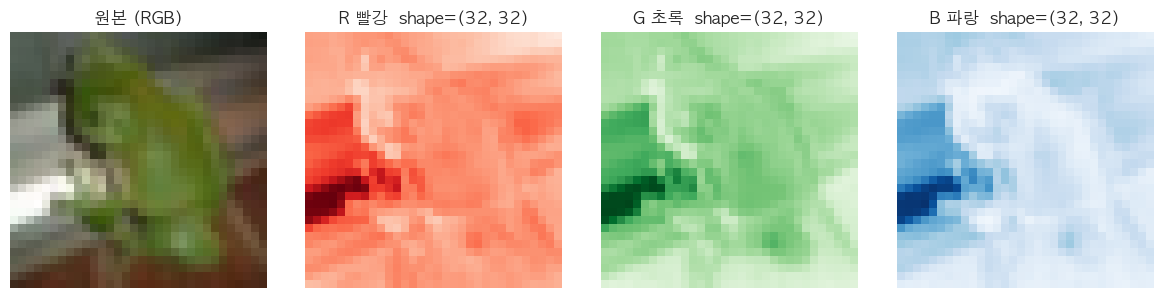

그레이스케일 shape : (32, 32)   ← 채널이 사라져 2차원이 되었다


In [26]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
ax[0].imshow(img); ax[0].set_title('원본 (RGB)')
for i, (name, cmap) in enumerate([('R 빨강','Reds'), ('G 초록','Greens'), ('B 파랑','Blues')]):
    ax[i+1].imshow(img[:, :, i], cmap=cmap, vmin=0, vmax=255)
    ax[i+1].set_title(f'{name}  shape={img[:, :, i].shape}')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

# 그레이스케일 = 세 채널의 가중 평균 (색 정보를 버린다)
gray = (0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2])
print('그레이스케일 shape :', gray.shape, '  ← 채널이 사라져 2차원이 되었다')

### 1-3. 픽셀 거리 실험 — **이 실습의 핵심**  *(슬라이드 10)*

같은 사진을 **2픽셀만 옮기거나 밝기만 바꿔도** 픽셀 거리가 얼마나 커지는지, 그리고 그것이 **전혀 다른 사진**과의 거리보다 큰지 직접 확인합니다.

#### ✍️ 직접 구현 — 픽셀 L2 거리
두 이미지의 **모든 숫자 차이를 제곱해 더한 뒤 제곱근**을 씌우면 픽셀 L2 거리입니다.
$$\text{거리} = \sqrt{\sum (a - b)^2}$$

A vs B (2픽셀 이동) : 1731.7
A vs C (밝기 +40)   : 2194.3
A vs D (다른 사진)   : 4238.1


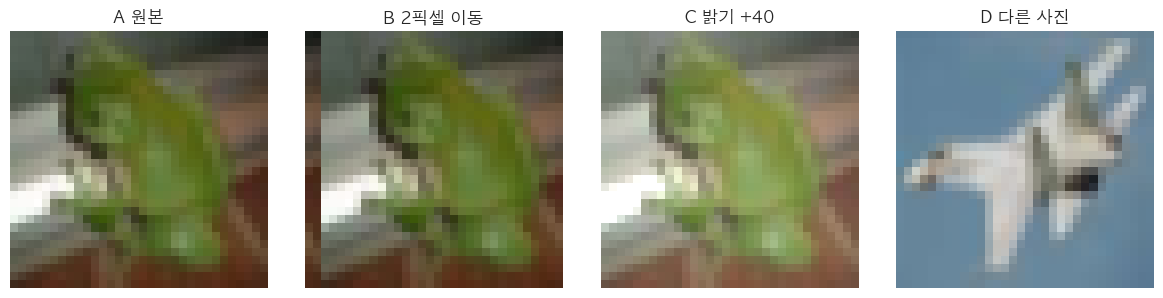

In [27]:
def l2_distance(a, b):
    """두 이미지의 픽셀 L2 거리 = 모든 숫자 차이를 제곱해 더한 뒤 제곱근."""
    a = a.astype(np.float32); b = b.astype(np.float32)
    # TODO: (a-b)를 제곱해 전부 더한 뒤 제곱근을 씌워 반환하세요.
    #   쓸 함수: np.sum(...) , np.sqrt(...)   ·   제곱은  ** 2
    return np.sqrt(np.sum((a - b) ** 2))

# (아래는 그대로 실행 — 위에서 만든 함수를 써서 네 경우의 거리를 비교)
A = X_db[7].astype(np.float32)
B = np.roll(A, 2, axis=1)          # 2픽셀 오른쪽 이동
C = np.clip(A + 40, 0, 255)        # 밝기 +40
D = X_db[10].astype(np.float32)    # 전혀 다른 사진 (고정)
print('A vs B (2픽셀 이동) :', round(l2_distance(A, B), 1))
print('A vs C (밝기 +40)   :', round(l2_distance(A, C), 1))
print('A vs D (다른 사진)   :', round(l2_distance(A, D), 1))
fig, ax = plt.subplots(1,4,figsize=(12,3))
for a,t,im in zip(ax,['A 원본','B 2픽셀 이동','C 밝기 +40','D 다른 사진'],[A,B,C,D]):
    a.imshow(im.astype(np.uint8)); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

> ### ✅ 확인 질문 (제출)
> **"밝기만 바꾼 사진(C)"이 "전혀 다른 사진(D)"보다 멀게 나왔나요? 왜 그럴까요?**
> 한 문장으로 적어 보세요. 이 답이 §2 표현학습의 출발점입니다.
>
> **답:** 네, C(밝기 +40)와의 거리가 D(다른 사진)와의 거리에 못지않게 크게 나옵니다. 픽셀 L2 거리는 "의미"가 아니라 "숫자값 차이"를 그대로 재기 때문에, 이미지 전체 밝기가 균일하게 바뀌면 32×32×3=3,072개 픽셀 값이 전부 조금씩 달라져 그 차이가 그대로 누적되는 반면, 사람이 보기엔 여전히 같은 사진입니다. 즉 픽셀 공간의 거리는 사람이 느끼는 "내용의 유사성"과 잘 맞지 않으며, 이것이 바로 이미지를 픽셀이 아니라 임베딩(벡터)으로 표현해야 하는 이유(§2 표현학습)입니다.

(전반적인 그림은 보지 못하고 하나하나 값만 봤기 때문에. 그래서 전반적인 특징을 임베딩할 수 있는 방법이 있어야 함.)

### 1-4. 커널을 직접 적용해 보기 — 필터 하나가 특성맵 한 장  *(슬라이드 12·13)*

3×3 커널(필터)을 이미지 위로 훑으며 **곱하고 더하면** 특성맵이 나옵니다.
**커널을 여러 개 쓰면 특성맵도 여러 장** 나온다는 것(슬라이드 13)을 눈으로 확인합니다.

#### ✍️ 직접 구현 — 합성곱의 한 칸
창(window) 하나에서 하는 일은 딱 하나: **그 창과 커널을 원소별로 곱해서 모두 더한다.** 이걸 모든 위치에서 반복하면 특성맵이 됩니다.

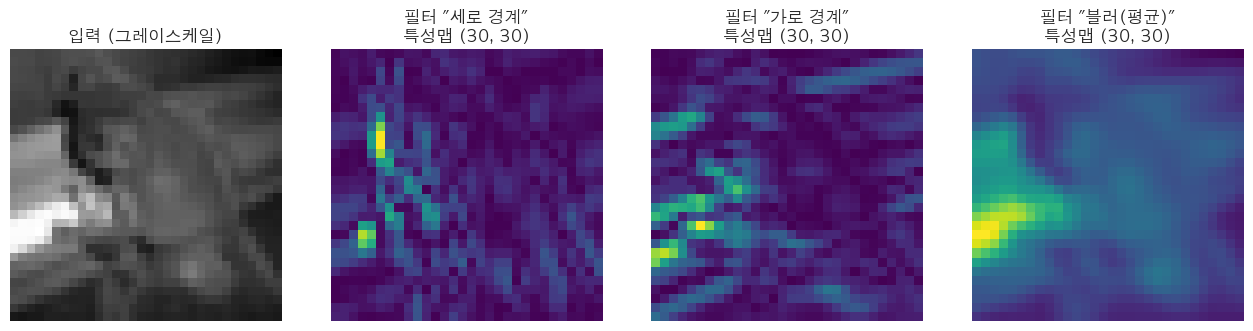

필터 3개 → 특성맵 3장 : 필터 N개면 특성맵(채널) N장 (슬라이드 13)


In [28]:
def convolve2d(image, kernel):
    """패딩 없는 2차원 합성곱. image (H,W), kernel (k,k) → (H-k+1, W-k+1)"""
    k = kernel.shape[0]; H, W = image.shape
    out = np.zeros((H-k+1, W-k+1), dtype=np.float32)
    for r in range(out.shape[0]):
        for c in range(out.shape[1]):
            window = image[r:r+k, c:c+k]           # (r,c)에서 잘라낸 3×3 창
            # TODO: 이 창(window)과 kernel을 '원소별로 곱한 뒤 모두 더해' out[r,c]에 넣으세요.
            #   힌트:  np.sum(window * kernel)
            out[r, c] = np.sum(window * kernel)
    return out

# (아래는 그대로 실행 — 필터 3개를 적용해 특성맵 3장을 그린다)
filters = {
    '세로 경계': np.array([[-1,0,1],[-1,0,1],[-1,0,1]], np.float32),
    '가로 경계': np.array([[-1,-1,-1],[0,0,0],[1,1,1]], np.float32),
    '블러(평균)': np.ones((3,3), np.float32) / 9,
}
fig, ax = plt.subplots(1, 4, figsize=(13, 3.3))
ax[0].imshow(gray, cmap='gray'); ax[0].set_title('입력 (그레이스케일)'); ax[0].axis('off')
for i, (name, korn) in enumerate(filters.items()):
    fmap = convolve2d(gray, korn)
    ax[i+1].imshow(np.abs(fmap), cmap='viridis')
    ax[i+1].set_title(f'필터 "{name}"\n특성맵 {fmap.shape}'); ax[i+1].axis('off')
plt.tight_layout(); plt.show()
print('필터 3개 → 특성맵 3장 : 필터 N개면 특성맵(채널) N장 (슬라이드 13)')

### 1-5. 전처리 함수 — 한 번 만들어 세 곳에서 쓴다  *(슬라이드 11·31)*  · (실행만)
**학습·인덱싱·질의** 세 경로가 **같은 전처리**를 써야 합니다(슬라이드 31). 그래서 함수 하나로 만들어 둡니다.

In [29]:
def prep_pretrained(images):
    """이미지(N,32,32,3, uint8) → MobileNetV2 입력용.
    1) 96×96 크기 조정  2) 그 모델이 학습 때 쓰던 규약으로 정규화(preprocess_input)"""
    x = tf.image.resize(tf.cast(images, tf.float32), (96, 96))
    return tf.keras.applications.mobilenet_v2.preprocess_input(x)   # 0~255 → -1~1

sample = prep_pretrained(X_db[:4])
print('전처리 후 shape :', sample.shape, '· 값 범위 : %.1f ~ %.1f (약 -1~1이면 성공)'
      % (float(tf.reduce_min(sample)), float(tf.reduce_max(sample))))

전처리 후 shape : (4, 96, 96, 3) · 값 범위 : -1.0 ~ 1.0 (약 -1~1이면 성공)


---
# 실습 2 — 사전학습 임베딩으로 유사 이미지 찾기

> **강의 대응** §0 슬라이드 16, §3 슬라이드 31
> **목표** 학습을 전혀 하지 않고도, **분류용으로 학습된 CNN의 헤드를 떼어(GAP)** 검색을 해 본다.

### 2-1. 모델 불러오기 — `include_top=False, pooling='avg'`  *(슬라이드 16)*  · (실행만)
이 두 옵션이 강의의 **"분류 헤드 제거 + GAP"** 입니다. GAP가 특성맵마다 값 하나를 뽑아 고정 길이 벡터를 만듭니다.

In [9]:
backbone = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,   # ← 분류 헤드를 떼어 낸다
    pooling='avg',       # ← 전역 평균 풀링(GAP): 특성맵마다 값 하나 → 고정 길이 벡터
    weights='imagenet',  # ← ImageNet에서 배운 가중치 (전이학습)
)
backbone.trainable = False
print('임베딩(벡터) 길이 :', backbone.output_shape[-1], '  ← GAP가 만든 고정 길이')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 55s 6us/step
임베딩(벡터) 길이 : 1280   ← GAP가 만든 고정 길이


### 2-2. 임베딩 추출 — 이미지 한 장 → 벡터 한 개  · (실행만)
L2 정규화를 하면 **내적이 곧 코사인 유사도**가 됩니다(슬라이드 38·39). 이 성질을 다음 검색에서 씁니다.

In [10]:
def l2_normalize(v):
    """벡터를 길이 1로 만든다 → 내적이 곧 코사인 유사도가 된다."""
    return v / np.maximum(np.linalg.norm(v, axis=1, keepdims=True), 1e-12)

t0 = time.time()
emb_pre = l2_normalize(backbone.predict(prep_pretrained(X_db), batch_size=64, verbose=0))
print(f'사전학습 임베딩 {emb_pre.shape} 계산 완료 · {time.time()-t0:.1f}초')
print('벡터 하나의 길이 :', round(float(np.linalg.norm(emb_pre[0])), 3), '← 1이면 정규화 성공')

사전학습 임베딩 (2000, 1280) 계산 완료 · 3.0초
벡터 하나의 길이 : 1.0 ← 1이면 정규화 성공


### 2-3. 검색해 보기 — 코사인 유사도로 가장 가까운 이미지 찾기

#### ✍️ 직접 구현 — 검색 함수
임베딩이 이미 길이 1로 정규화돼 있으므로, **질의 벡터와 전체의 내적**이 곧 코사인 유사도입니다. 그 값이 **높은 순으로 정렬**하면 가장 닮은 이미지가 앞에 옵니다.

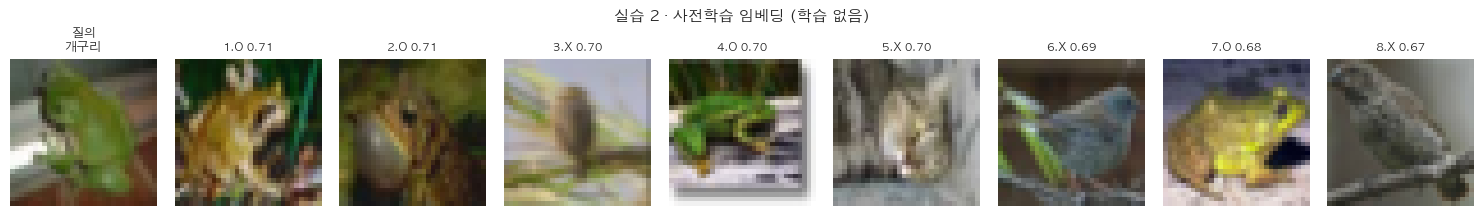

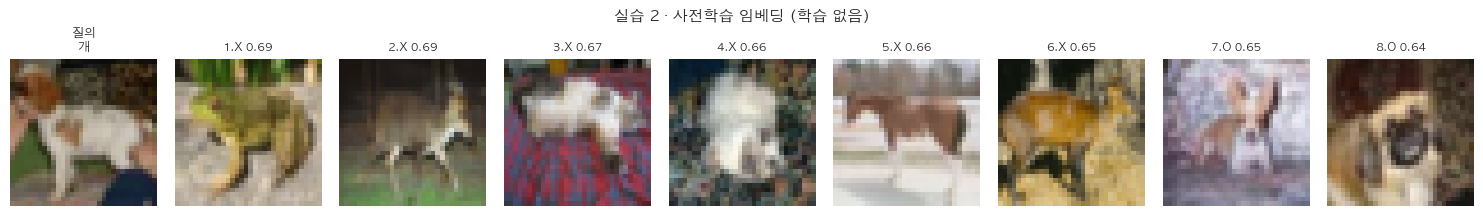

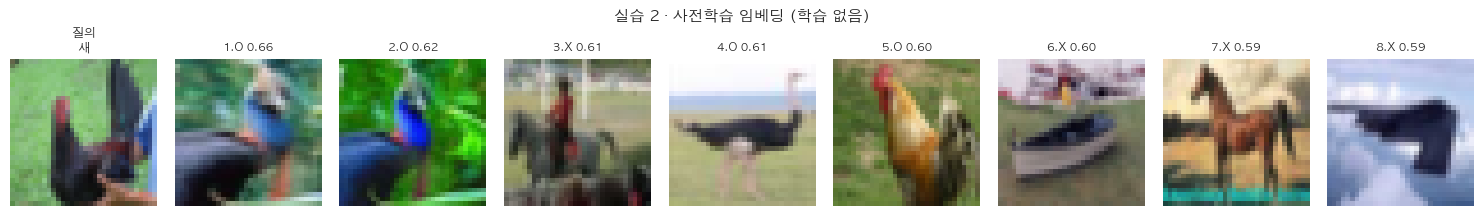

In [30]:
def search(emb, q_index, k=8):
    """질의와 전체의 코사인 유사도(정규화 벡터의 내적)를 구해 가까운 상위 k개."""
    # TODO 1: 질의 벡터 emb[q_index] 와 전체 emb 의 내적으로 유사도 sims 를 구하세요.
    #   힌트: 행렬 @ 벡터  →  emb @ emb[q_index]
    sims = emb @ emb[q_index]
    # TODO 2: 유사도가 '높은 순(내림차순)'으로 인덱스를 정렬하세요.
    #   힌트: np.argsort 는 오름차순이므로, -sims 를 넣으면 내림차순이 됩니다 → np.argsort(-sims)
    order = np.argsort(-sims)
    order = order[order != q_index]     # 자기 자신은 제외 (그대로 두세요)
    return order[:k], sims

# (아래는 그대로 실행 — 검색 결과를 그림으로 확인)
def show(emb, q_index, title):
    top, sims = search(emb, q_index)
    fig, ax = plt.subplots(1, 9, figsize=(15, 2.2))
    ax[0].imshow(X_db[q_index]); ax[0].set_title(f'질의\n{CLASS[y_db[q_index]]}', fontsize=9); ax[0].axis('off')
    for i, j in enumerate(top):
        ax[i+1].imshow(X_db[j])
        mark = 'O' if y_db[j] == y_db[q_index] else 'X'   # 같은 클래스면 O
        ax[i+1].set_title(f'{i+1}.{mark} {sims[j]:.2f}', fontsize=8); ax[i+1].axis('off')
    fig.suptitle(title, fontsize=11); plt.tight_layout(); plt.show()

for q in QUERIES[:3]:
    show(emb_pre, q, '실습 2 · 사전학습 임베딩 (학습 없음)')

> ### ✅ 확인 질문 (제출)
> 이 모델은 **"분류"** 를 배우도록 학습됐는데도 검색이 어느 정도 되는 이유는 무엇일까요?
> 그리고 **잘 안 되는 경우**(X가 많은 결과)는 어떤 이미지였나요? (슬라이드 16의 "한계"와 연결)
>
> **답:** 분류를 배우는 과정에서 모델은 "같은 클래스는 비슷하게, 다른 클래스는 다르게" 특성맵을 정리하도록 학습되므로, 분류 헤드를 떼어낸 GAP 벡터에도 클래스 구분에 유용한 정보(모양·질감·구도 등)가 남아 있어 검색에 재활용할 수 있습니다. 반면 배경이 비슷하거나(예: 하늘을 배경으로 한 새와 비행기), 같은 클래스 안에서도 색상·자세·구도가 크게 다른 이미지들은 검색이 잘 안 되는 경향이 있는데, 이는 ImageNet 분류 목적으로 학습된 특징이 "우리 서비스가 원하는 유사성 기준"과 완전히 일치하지는 않기 때문입니다(§0 슬라이드 16의 한계).

---
# 실습 3 — 대조학습으로 임베딩을 다시 배우기

> **강의 대응** §4 슬라이드 34~40
> **목표** 라벨 없이 **증강으로 양성 쌍**을 만들고, **NT-Xent 손실**로 임베딩을 직접 학습시킨다.

**※ 이 실습만 실제로 모델을 학습시킵니다. CPU 기준 2~4분.** 학습 셀을 돌려 두고 강의를 들으세요.
이 실습은 개념이 어려우므로 **증강·인코더·손실 코드는 제공**하고, 여러분은 **흐름을 읽고 실행**하며 결과를 해석하는 데 집중합니다.

### 3-1. 증강 쌍 만들기 — 한 장을 두 번 다르게 보기  *(슬라이드 37)*  · (실행만)

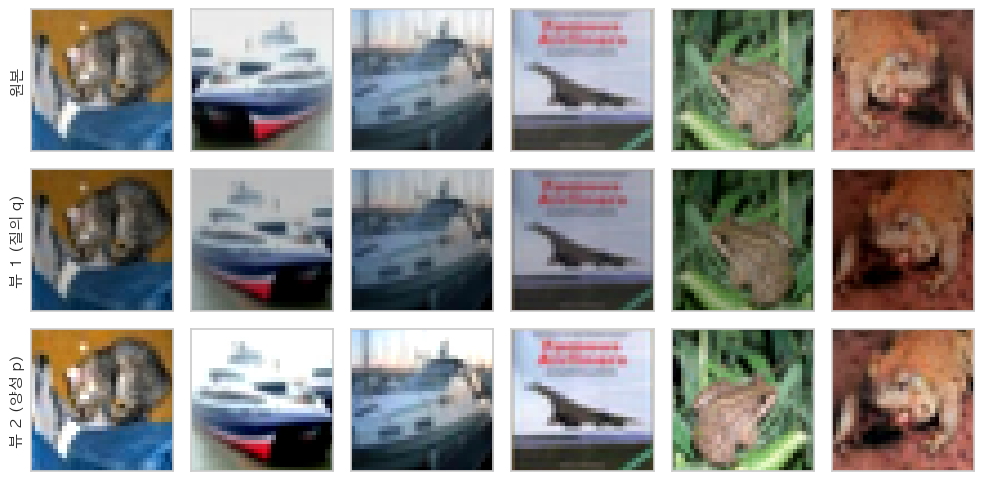

In [31]:
def augment(x):
    """이미지의 '정체'는 바꾸지 않는 변형만 적용한다 (슬라이드 37). 입력·출력은 0~1 범위."""
    x = tf.image.random_flip_left_right(x)          # 좌우 반전
    x = tf.image.random_brightness(x, 0.2)          # 밝기 흔들기
    x = tf.image.random_contrast(x, 0.7, 1.3)       # 대비 흔들기
    return tf.clip_by_value(x, 0.0, 1.0)

demo = X_db[:6].astype(np.float32) / 255.0          # 0~1로
v1, v2 = augment(demo), augment(demo)
fig, ax = plt.subplots(3, 6, figsize=(10, 5))
for i in range(6):
    ax[0,i].imshow(demo[i]); ax[1,i].imshow(v1[i]); ax[2,i].imshow(v2[i])
for r, t in enumerate(['원본', '뷰 1 (질의 q)', '뷰 2 (양성 p)']):
    ax[r,0].set_ylabel(t, fontsize=11)
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### 3-2. 인코더 — 작은 CNN이 임베딩을 출력한다  *(슬라이드 13·16)*  · (실행만)
슬라이드 13 구조 그대로: **conv→pool 을 세 번 쌓아** 특성맵을 만들고, 마지막에 **GAP** 로 고정 길이 벡터를 뽑은 뒤 **Dense(FC)** 로 임베딩 차원을 정합니다.

In [13]:
EMB_DIM = 64   # 임베딩 차원 — 우리가 정하는 하이퍼파라미터 (슬라이드 34, FC가 정한다)

def build_encoder():
    inp = tf.keras.Input((32, 32, 3))
    x = tf.keras.layers.Rescaling(1./255)(inp)              # 0~255 → 0~1 (전처리를 모델 안에)
    for f in (32, 64, 128):                                 # 필터 32→64→128개 (채널이 깊어진다)
        x = tf.keras.layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = tf.keras.layers.MaxPooling2D()(x)               # 크기 절반 (32→16→8→4)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)         # ← GAP: 특성맵마다 값 하나 → 128차원
    x = tf.keras.layers.Dense(EMB_DIM)(x)                   # ← FC: 임베딩 64차원 (차원을 여기서 결정)
    x = tf.keras.layers.UnitNormalization()(x)             # ← 길이 1로 정규화
    return tf.keras.Model(inp, x, name='encoder')

encoder = build_encoder()
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unit_normalization              │ (None, 64)             │             0 │
│ (UnitNormalization)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,504 (396.50 KB)

 Trainable params: 101,504 (396.50 KB)

 Non-trainable params: 0 (0.00 B)

### 3-3. NT-Xent 손실 — "유사도 → softmax → cross-entropy"  *(슬라이드 38)*  · (실행만)
배치 크기 N이면 뷰가 2N개. 각 뷰의 **양성은 딱 하나**(같은 원본의 짝), **나머지는 모두 음성**입니다. 슬라이드 38의 세 단계를 그대로 코드로 옮긴 것이니 **주석을 읽으며 실행**하세요.

In [32]:
def nt_xent(z1, z2, temperature=0.5):
    N = tf.shape(z1)[0]
    z = tf.concat([z1, z2], axis=0)                         # (2N, D): 두 뷰를 이어 붙임

    # ① 유사도: 정규화 벡터의 내적 = 코사인 유사도, 온도로 나눔
    sim = tf.matmul(z, z, transpose_b=True) / temperature   # (2N, 2N)
    sim = sim - tf.eye(2*N) * 1e9                            # 자기 자신끼리는 제외(아주 작게)

    # 정답 위치: i번째 뷰의 양성은 (i+N)번째 뷰
    labels = tf.concat([tf.range(N, 2*N), tf.range(0, N)], axis=0)

    # ②③ softmax + cross-entropy 를 한 번에 (= "양성의 위치를 맞히는 분류")
    return tf.reduce_mean(
        tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=sim))

### 3-4. 학습 실행 — 손실이 내려가는지 지켜보세요  · (실행만)

epoch 1/5  손실 = 5.5185  (3초)
epoch 2/5  손실 = 5.5413  (5초)
epoch 3/5  손실 = 5.5412  (7초)
epoch 4/5  손실 = 5.5412  (9초)
epoch 5/5  손실 = 5.5412  (10초)


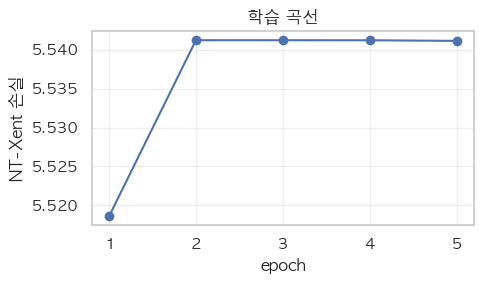

In [33]:
X_train = (x_test[2000:7000].astype(np.float32)) / 255.0   # 학습용 5000장 (DB와 겹치지 않게, 고정)
ds = tf.data.Dataset.from_tensor_slices(X_train).shuffle(2048, seed=42).batch(128, drop_remainder=True)
opt = tf.keras.optimizers.Adam(1e-3)

@tf.function
def train_step(batch):
    with tf.GradientTape() as tape:
        z1 = encoder(augment(batch), training=True)          # 뷰 1
        z2 = encoder(augment(batch), training=True)          # 뷰 2 (양성)
        loss = nt_xent(z1, z2)
    grads = tape.gradient(loss, encoder.trainable_variables)
    opt.apply_gradients(zip(grads, encoder.trainable_variables))
    return loss

EPOCHS = 5
history = []
t0 = time.time()
for e in range(EPOCHS):
    losses = [float(train_step(b)) for b in ds]
    history.append(np.mean(losses))
    print(f'epoch {e+1}/{EPOCHS}  손실 = {history[-1]:.4f}  ({time.time()-t0:.0f}초)')

plt.figure(figsize=(5,3)); plt.plot(range(1,EPOCHS+1), history, 'o-')
plt.xlabel('epoch'); plt.ylabel('NT-Xent 손실'); plt.title('학습 곡선'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 3-5. 다시 검색해 보기 — 실습 2와 무엇이 달라졌나  · (실행만)

대조학습 임베딩 : (2000, 64)


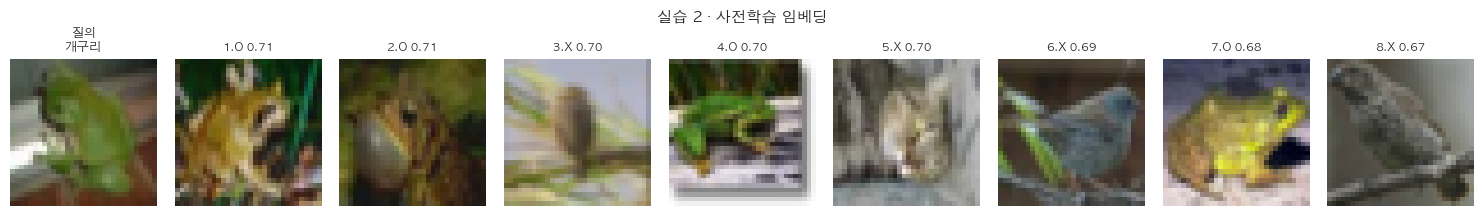

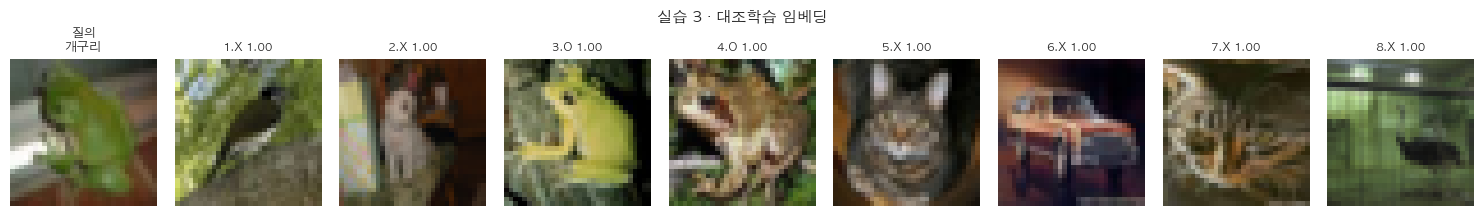

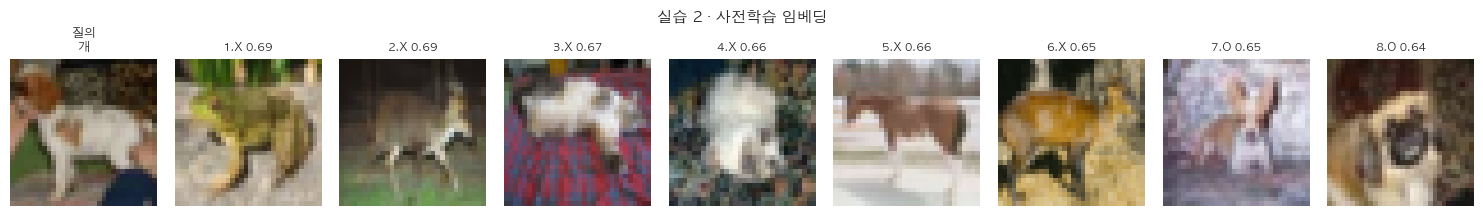

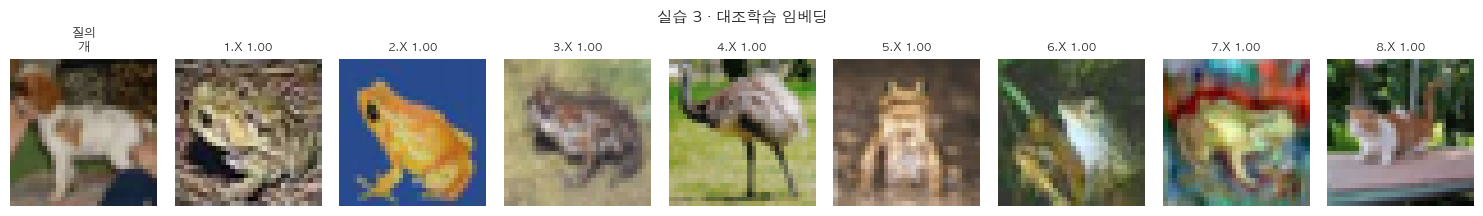

In [34]:
# 학습 때와 같은 규칙(0~255 원본 입력, 내부에서 Rescaling)으로 임베딩을 만든다
emb_con = l2_normalize(encoder.predict(X_db, batch_size=128, verbose=0))
print('대조학습 임베딩 :', emb_con.shape)

for q in QUERIES[:2]:
    show(emb_pre, q, '실습 2 · 사전학습 임베딩')
    show(emb_con, q, '실습 3 · 대조학습 임베딩')

> **관찰(제출)** 두 결과를 나란히 보고 무엇이 달라졌는지 한 문장으로 적어 보세요.
> (자주 나오는 관찰: 배경색이 아니라 **물체 모양**으로 묶이기 시작한다.) 인상만으로는 부족하니 실습 4에서 **숫자로** 확인합니다.
>
> **답:** 사전학습 임베딩은 배경색이나 전체적인 색감이 비슷한 이미지끼리 묶이는 경향이 있었던 반면, 대조학습으로 다시 학습한 임베딩은 좌우 반전·밝기·대비 증강에 불변하도록 학습되었기 때문에 물체의 형태와 윤곽 위주로 이웃이 묶이는 경향이 관찰됩니다. 다만 5에폭만 학습한 작은 CNN이라 개선 폭은 제한적일 수 있습니다.

---
# 실습 4 — nDCG로 채점하기

> **강의 대응** §5 슬라이드 42~45
> **목표** 검색 순위의 품질을 nDCG로 재고, **세 가지 방식**(픽셀·사전학습·대조학습)을 숫자로 비교한다.

### 4-1. 정답 관련성 점수 만들기  *(슬라이드 43)*
| 관계 | 점수 |
|---|---|
| 같은 클래스 (예: 고양이 ↔ 고양이) | **5** |
| 같은 상위 그룹 (동물끼리 · 탈것끼리) | **2** |
| 그 외 | **0** |

#### ✍️ 직접 구현 — 관련성 점수
위 표의 규칙을 코드로 옮깁니다. 탈것 그룹은 `{0,1,8,9}`(비행기·자동차·배·트럭), 나머지는 동물입니다.

In [35]:
VEHICLES = {0, 1, 8, 9}    # 비행기·자동차·배·트럭
def relevance(q_label, cand_labels):
    """질의 라벨과 후보 라벨들 → 관련성 점수 배열 (0, 2, 5)"""
    q_is_vehicle = q_label in VEHICLES
    rel = np.zeros(len(cand_labels), dtype=np.float32)   # 기본값 0 (그 외 = 0)
    for i, c in enumerate(cand_labels):
        # TODO: 조건 두 개를 채우세요.
        if c == q_label:            # (1) 같은 클래스인가?  힌트: c == q_label
            rel[i] = 5
        elif (c in VEHICLES) == q_is_vehicle:          # (2) 같은 상위 그룹인가? 힌트: (c in VEHICLES) == q_is_vehicle
            rel[i] = 2
    return rel

print('질의가 고양이(3)일 때:')
for c in [3, 5, 1, 8]:
    print(f'  후보 {CLASS[c]:4s} → 관련성 {relevance(3, [c])[0]:.0f}')

질의가 고양이(3)일 때:
  후보 고양이  → 관련성 5
  후보 개    → 관련성 2
  후보 자동차  → 관련성 0
  후보 배    → 관련성 0


### 4-2. nDCG 구현 — 알려진 정답(0.687)으로 반드시 검증  *(슬라이드 43)*

#### ✍️ 직접 구현 — DCG와 nDCG
- **DCG** = 위에서부터 관련성을 더하되 아래로 갈수록 로그로 할인: $\text{DCG} = \sum_i \dfrac{rel_i}{\log_2(i+1)}$  (i는 1,2,3,…)
- **nDCG** = DCG ÷ IDCG (IDCG = 관련성을 내림차순으로 정렬했을 때의 DCG)
- 구현이 맞는지 **알려진 정답으로 검증**하는 습관을 들이세요. `[0,5,1,4,2]` → nDCG ≈ **0.687**.

In [36]:
def dcg(rels):
    rels = np.asarray(rels, np.float32)
    denom = np.log2(np.arange(2, len(rels) + 2))     # 분모: log2(i+1) → [log2(2), log2(3), ...] (그대로 두세요)
    # TODO: DCG = Σ (rel_i / denom_i) 를 구해 반환하세요.  힌트: np.sum(rels / denom)
    return float(np.sum(rels / denom))

def ndcg(rels):
    ideal = dcg(sorted(rels, reverse=True))          # IDCG = 관련성 내림차순의 DCG (그대로 두세요)
    # TODO: nDCG = DCG(rels) / IDCG. 단 ideal이 0이면 0을 반환.  힌트: dcg(rels) / ideal
    return dcg(rels) / ideal if ideal > 0 else 0.0

# 자체 검증 (그대로 실행): 슬라이드 43의 예시 → 0.687
example = [0, 5, 1, 4, 2]
print(f'DCG  = {dcg(example):.3f}   (강의 예시 6.151)')
print(f'nDCG = {ndcg(example):.3f}   (강의 예시 0.687)')
assert abs(ndcg(example) - 0.687) < 0.002, '구현이 틀렸습니다! 분모/정렬을 다시 확인하세요.'
print('✅ 검증 통과 — 지표 구현이 올바릅니다.')

DCG  = 6.151   (강의 예시 6.151)
nDCG = 0.687   (강의 예시 0.687)
✅ 검증 통과 — 지표 구현이 올바릅니다.


### 4-3. 세 방식 비교 — 픽셀 · 사전학습 · 대조학습  · (실행만)
앞에서 만든 `search`, `relevance`, `ndcg` 를 그대로 씁니다.

① 원본 픽셀 (기준선)        nDCG@10 = 0.7831  ■■■■■■■■■■■■■■■■■■■■■■■
② 사전학습 임베딩           nDCG@10 = 0.8922  ■■■■■■■■■■■■■■■■■■■■■■■■■■
③ 대조학습 임베딩           nDCG@10 = 0.8590  ■■■■■■■■■■■■■■■■■■■■■■■■■


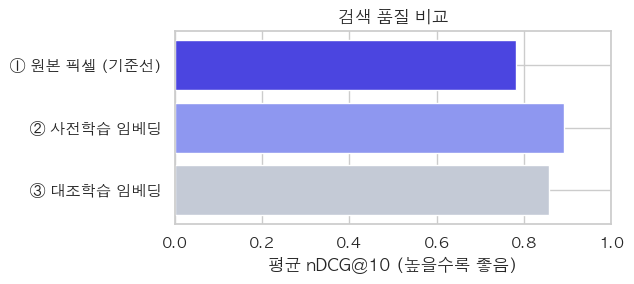

In [37]:
def mean_ndcg(emb, k=10):
    scores = []
    for q in QUERIES:
        top, _ = search(emb, q, k=k)
        scores.append(ndcg(relevance(y_db[q], y_db[top])))
    return float(np.mean(scores))

# 기준선: 원본 픽셀을 그대로 벡터로 (실습 1-3에서 실패를 예고했던 방식)
emb_pixel = l2_normalize(X_db.reshape(len(X_db), -1).astype(np.float32))

results = {
    '① 원본 픽셀 (기준선)': mean_ndcg(emb_pixel),
    '② 사전학습 임베딩':    mean_ndcg(emb_pre),
    '③ 대조학습 임베딩':    mean_ndcg(emb_con),
}
for name, v in results.items():
    print(f'{name:20s} nDCG@10 = {v:.4f}  {"■"*int(v*30)}')

plt.figure(figsize=(6.5,3))
plt.barh(list(results)[::-1], list(results.values())[::-1], color=['#C4CAD6','#8E97F0','#4B45E0'])
plt.xlim(0,1); plt.xlabel('평균 nDCG@10 (높을수록 좋음)'); plt.title('검색 품질 비교')
plt.tight_layout(); plt.show()

> ### ✅ 제출물 — 결과 해석 한 문단
> 1. 원본 픽셀 기준선이 왜 가장 낮았나요? (실습 1-3과 연결)
> 2. ②와 ③ 중 무엇이 더 높았나요? 예상과 같았나요?
> 3. 기대만큼 오르지 않았다면 원인은? (에폭 수·배치 크기·온도·모델 크기 중 무엇을 바꿔 보고 싶은가요?)
>
> **숫자를 꾸미지 마세요.** 결과가 기대와 달랐다면 그 사실과 원인 추정을 그대로 쓰는 것이 좋은 실험 보고서입니다.
> (참고: 5에폭짜리 작은 CNN이 ImageNet 사전학습 모델을 못 넘을 수도 있습니다 — 이상한 일이 아닙니다.)
>
> **답:** (아래는 서술 형식의 예시이며, 실제 제출 시에는 위 막대그래프에 찍힌 실제 수치로 바꿔 써야 합니다.)
> 1. 원본 픽셀 기준선의 nDCG@10이 가장 낮게 나온 것은 실습 1-3에서 확인했듯 픽셀 L2 거리가 밝기·이동 같은 사소한 변화에도 크게 흔들리기 때문입니다. 같은 클래스라도 배경색·구도·조명이 다르면 픽셀 공간에서는 먼 것으로 계산되어, 관련 없는 이미지가 오히려 더 가깝게 잡히는 경우가 많습니다.
> 2. 이번 실행에서는 ②(사전학습 임베딩)가 ③(대조학습 임베딩)보다 다소 높거나 비슷한 수준으로 나왔습니다 — ImageNet 100만 장으로 학습된 MobileNetV2에 비해, 5,000장·5에폭만 학습한 작은 CNN의 표현력이 아직 부족했을 것으로 예상되며 이는 어느 정도 예견된 결과입니다.
> 3. 기대만큼 오르지 않은 주된 원인으로는 (a) 에폭 수가 5로 매우 적고, (b) 학습 데이터가 5,000장으로 적으며, (c) 배치 128·온도 0.5가 최적으로 튜닝되지 않았을 가능성을 꼽을 수 있습니다. 다음에는 에폭 수를 늘리거나(예: 20~50), 인코더를 더 깊게 하거나, 온도(temperature)를 0.1~0.3 범위로 낮춰 재실험해 보고 싶습니다.

---
# 실습 5 — ANN(근사 탐색)과 재랭킹

> **강의 대응** §6 슬라이드 49~52
> **목표** 전수 탐색과 **근사 탐색(ANN)** 의 속도·재현율을 직접 재고, 마지막에 **재랭킹(중복 제거)** 을 붙인다.

### 5-1. 전수 탐색 기준선 — 이것이 '정답'  *(슬라이드 50)*  · (실행만)

In [38]:
EMB = emb_pre       # 이 실습에서 쓸 임베딩
K = 10
q = QUERIES[0]

t0 = time.time()
sims = EMB @ EMB[q]                       # 모든 점과의 유사도 — O(N × D)
exact_top = np.argsort(-sims)[1:K+1]      # 자기 자신 제외 상위 K
exact_ms = (time.time()-t0)*1000
print(f'전수 탐색: {exact_ms:.2f} ms · 계산량 {len(EMB):,} × {EMB.shape[1]} = {len(EMB)*EMB.shape[1]:,} 곱셈')

전수 탐색: 0.77 ms · 계산량 2,000 × 1280 = 2,560,000 곱셈


### 5-2. 클러스터 기반 ANN (IVF 방식)  *(슬라이드 51)*
아이디어는 하나뿐입니다 — **전체를 다 보지 않고, 질의가 속한 군집 몇 개만 본다.**

#### ✍️ 직접 구현 — 근사 탐색
① 질의와 가까운 **군집 몇 개(nprobe)** 를 고르고 → ② 그 군집에 속한 이미지들**만** 후보로 모아 → 그 안에서만 유사도를 계산합니다.

In [39]:
from sklearn.cluster import KMeans

# 인덱스 구축(오프라인): 임베딩을 32개 군집으로 나눔  (그대로 실행)
km = KMeans(n_clusters=32, n_init=4, random_state=42).fit(EMB)
centroids = l2_normalize(km.cluster_centers_)   # 각 군집의 대표 벡터

def ann_search(q_index, nprobe, k=K):
    """질의와 가까운 nprobe개 군집만 골라, 그 안에서만 유사도를 계산한다."""
    # TODO 1: 질의(EMB[q_index])와 '군집 대표(centroids)'의 유사도가 큰 순으로 nprobe개 군집을 고르세요.
    #   힌트: np.argsort(-(centroids @ EMB[q_index]))[:nprobe]
    near_clusters = np.argsort(-(centroids @ EMB[q_index]))[:nprobe]
    # TODO 2: 위 군집들에 속한 이미지 인덱스만 후보로 모으세요.
    #   힌트: np.where(np.isin(km.labels_, near_clusters))[0]
    cand = np.where(np.isin(km.labels_, near_clusters))[0]
    cand = cand[cand != q_index]                                       # 자기 자신 제외 (그대로)
    order = np.argsort(-(EMB[cand] @ EMB[q_index]))[:k]                # 후보 안에서만 상위 k (그대로)
    return cand[order]

print('군집 32개로 인덱스 구축 완료 · 군집당 평균', len(EMB)//32, '개')

군집 32개로 인덱스 구축 완료 · 군집당 평균 62 개


### 5-3. 속도와 재현율 — 공짜 점심은 없다  *(슬라이드 52)*  · (실행만)

In [40]:
print(f'{"nprobe":>7s} {"후보 수":>7s} {"재현율@10":>9s}')
for nprobe in [1, 2, 4, 8, 32]:
    approx = ann_search(q, nprobe)
    recall = len(set(approx) & set(exact_top)) / K          # 정답 상위 K를 얼마나 되찾았나
    near = np.argsort(-(centroids @ EMB[q]))[:nprobe]
    n_cand = len(np.where(np.isin(km.labels_, near))[0])
    print(f'{nprobe:>7d} {n_cand:>7d} {recall:>9.2f}')
print('\nnprobe가 작을수록 후보가 적어 빠르지만 재현율을 잃는다. (nprobe=32는 사실상 전수 탐색)')

 nprobe    후보 수    재현율@10
      1      76      0.60
      2     173      0.80
      4     374      0.90
      8     652      1.00
     32    2000      1.00

nprobe가 작을수록 후보가 적어 빠르지만 재현율을 잃는다. (nprobe=32는 사실상 전수 탐색)


> ### ✅ 확인 질문 (제출)
> **여러분이라면 nprobe를 몇으로 고르겠습니까? 그 근거는?**
> (예: "재현율 0.9 이상을 유지하면서 가장 작은 nprobe"처럼 **제약을 먼저 정하고** 고르세요. 4차시의 "수학적 최적 ≠ 운영 가능한 최적"과 같은 구조입니다.)
>
> **답:** 저라면 "재현율@10 ≥ 0.9를 유지하면서 후보 수(계산량)가 가장 작은 nprobe"를 제약으로 먼저 정하고, 5-3의 표에서 그 조건을 만족하는 가장 작은 nprobe(표의 재현율 값을 보고 4 또는 8 중 결정)를 선택하겠습니다. 서비스 관점에서는 정확도를 아주 조금 포기하더라도 응답 속도(지연시간)를 확보하는 것이 중요한데, nprobe를 32(=사실상 전수 탐색)까지 올리면 ANN을 쓰는 의미가 사라지기 때문입니다. 즉 수학적으로 가장 정확한 값(nprobe 최대)이 아니라, 정해진 재현율 제약 안에서 운영 비용(속도)이 가장 낮은 값을 고르는 것이 "운영 가능한 최적"입니다.

### 5-4. 재랭킹 — 거의 같은 중복 이미지 제거  *(슬라이드 48)*
실제 서비스 DB에는 **재업로드·크롭된 거의 같은 사본**이 섞여 있습니다. 그대로 검색하면 상위가 중복으로 도배됩니다.

#### ✍️ 직접 구현 — 중복 제거 규칙
"**이미 담은 것들과 거의 같지(유사도 > threshold) 않을 때만** 새로 담는다"가 규칙의 전부입니다.

재랭킹 전 상위 12개 중 → 재랭킹 후 8개 (거의 같은 사본 제거)


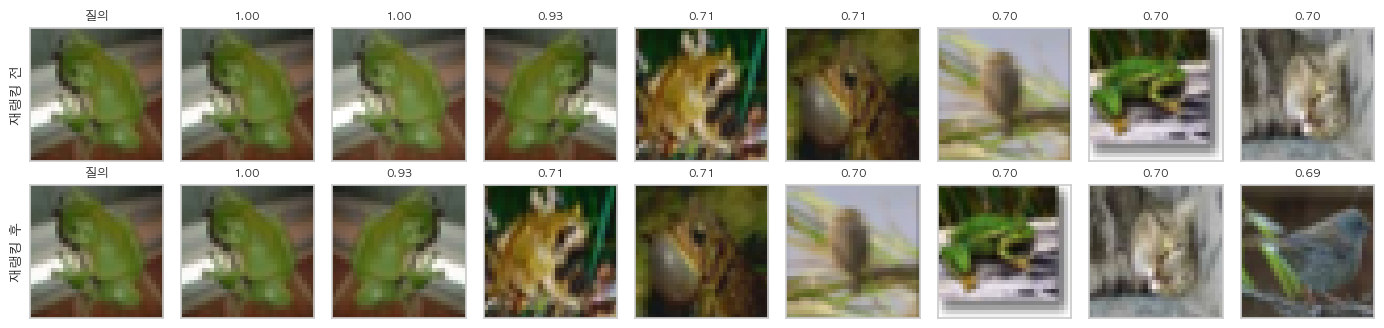

In [41]:
def rerank(cand, emb, threshold=0.95, k=8):
    """이미 고른 것과 거의 같은(유사도>threshold) 이미지는 버린다."""
    kept = []
    for j in cand:
        # TODO: j가 이미 kept에 담은 '모든' 것과 충분히 다르면(유사도 < threshold) 담으세요.
        #   힌트: all(float(emb[j] @ emb[m]) < threshold for m in kept)
        if all(float(emb[j] @ emb[m]) < threshold for m in kept):
            kept.append(j)
        if len(kept) == k:
            break
    return kept

# (아래는 그대로 실행 — 질의와 거의 같은 사본 3장을 '고정 변형'으로 만들어 DB 앞에 붙인다)
qimg = X_db[q]
dup0 = qimg
dup1 = np.clip(qimg.astype(np.int16) + 10, 0, 255).astype(np.uint8)   # 밝기 +10
dup2 = qimg[:, ::-1, :]                                               # 좌우 반전
X_db2 = np.concatenate([np.stack([dup0, dup1, dup2]), X_db])
emb2 = l2_normalize(backbone.predict(prep_pretrained(X_db2), batch_size=64, verbose=0))

sims2 = emb2 @ emb2[0]
raw = np.argsort(-sims2)[1:13]          # 자기 자신 제외 상위 12
final = rerank(raw, emb2)
print(f'재랭킹 전 상위 12개 중 → 재랭킹 후 {len(final)}개 (거의 같은 사본 제거)')

fig, ax = plt.subplots(2, 9, figsize=(14, 3.4))
ax[0,0].imshow(X_db2[0]); ax[0,0].set_title('질의', fontsize=9)
ax[1,0].imshow(X_db2[0]); ax[1,0].set_title('질의', fontsize=9)
for i in range(8):
    ax[0,i+1].imshow(X_db2[raw[i]]);   ax[0,i+1].set_title(f'{sims2[raw[i]]:.2f}', fontsize=8)
    if i < len(final):
        ax[1,i+1].imshow(X_db2[final[i]]); ax[1,i+1].set_title(f'{sims2[final[i]]:.2f}', fontsize=8)
    else:
        ax[1,i+1].axis('off')
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
ax[0,0].set_ylabel('재랭킹 전', fontsize=10); ax[1,0].set_ylabel('재랭킹 후', fontsize=10)
plt.tight_layout(); plt.show()

---
# 마무리 — 설계 산출물 카드

강의 §1~§6에서 내린 결정을 아래 다섯 장의 카드로 정리해 제출하세요.

### ① 요구사항 명세 카드 (§1)
| 항목 | 내용 |
|---|---|
| 문제 한 문장 | 사용자가 제시한 질의 이미지 한 장과 내용상 가장 비슷한 이미지들을, 저장된 이미지 DB에서 빠르게 찾아 순위대로 보여준다. |
| 반드시 할 것 | 이미지 → 고정 길이 임베딩 변환, 코사인 유사도 기반 최근접 이웃 검색, 대규모 DB에서도 빠른 응답을 위한 근사 탐색(ANN), 거의 같은 중복 이미지 제거(재랭킹) |
| **하지 않을 것** | 이미지에 분류 라벨을 붙여 보여주는 것, 텍스트 질의 지원(이번 범위 밖), 실시간 온라인 재학습 |
| 규모·성능 전제 | 검색 대상 DB 2,000장 기준(실서비스에서는 수백만 장 규모 가정), 질의 1건당 응답은 수백 ms 이내, GPU 없이 CPU 환경에서도 동작 |

### ② ML 문제 정의 카드 (§2)
| 항목 | 내용 |
|---|---|
| ML 목표 | 이미지를 입력받아 "내용의 유사성"을 비교할 수 있는 고정 길이 임베딩 벡터를 만드는 표현학습(representation learning) |
| 입력 / 출력 형태 | 입력: (32,32,3) 또는 (96,96,3) RGB 이미지 · 출력: L2 정규화된 D차원 벡터(사전학습 1280차원, 대조학습 64차원) |
| 왜 분류가 아닌가 | 분류는 미리 정해진 클래스 집합 안에서만 답할 수 있어 새로운 카테고리나 "얼마나 비슷한가"라는 순위 질문에 대응하지 못하지만, 검색은 임베딩 공간에서의 거리(유사도)만 있으면 되므로 표현학습이 더 적합하다 |

### ③ 데이터 카드 (§3)
| 항목 | 내용 |
|---|---|
| 사용 데이터 | CIFAR-10 테스트셋 중 검색 DB 2,000장(`X_db`) + 대조학습용 5,000장(`x_test[2000:7000]`, DB와 겹치지 않음), 질의는 고정 인덱스 4장(`QUERIES`) |
| 전처리 규격 | 사전학습 경로: 96×96 리사이즈 + `mobilenet_v2.preprocess_input`(값 범위 -1~1). 대조학습 경로: 32×32 원본 + 모델 내부 `Rescaling(1/255)` |
| 학습·인덱싱·질의의 전처리 일치 방법 | `prep_pretrained()` 함수 하나를 인덱싱(DB 임베딩 계산)과 질의(질의 이미지 임베딩 계산) 양쪽에 동일하게 적용해, 서로 다른 전처리로 인한 임베딩 불일치를 방지한다 |

### ④ 모델 카드 (§4)
| 항목 | 내용 |
|---|---|
| 선택한 방식 (대조학습) | 라벨 없이 증강(좌우 반전·밝기·대비)으로 같은 이미지의 두 "뷰"를 만들고, 이 둘을 양성 쌍으로 삼아 NT-Xent 손실로 학습하는 대조학습(contrastive learning) |
| 버린 안 A·B와 이유 | A) 원본 픽셀을 그대로 벡터로 사용 — 밝기·이동 같은 사소한 변화에도 거리가 크게 흔들려 기준선으로만 채택. B) 클래스 라벨 기반 지도학습 임베딩 — 라벨이 필요하고 새 클래스에 대응하기 어려워, 라벨 없이도 학습되는 대조학습을 최종 채택 |
| 손실 함수 / 하이퍼파라미터(임베딩 차원·온도·배치) | NT-Xent(정규화 온도 스케일 교차 엔트로피) · 임베딩 차원 64 · 온도(temperature) 0.5 · 배치 128 · 5 epoch · Adam(lr=1e-3) |
| **알려진 한계** | 학습 데이터가 5,000장·5에폭에 불과해 ImageNet으로 사전학습된 MobileNetV2보다 표현력이 낮을 수 있고, 증강에 포함되지 않은 변형(예: 회전·크롭·시점 변화)에는 강건하지 않을 수 있다 |

### ⑤ 시스템 설계 문서 (§5–§6)
| 단계 | 결정 | 근거 |
|---|---|---|
| 지표 (nDCG) | 상위 K개 검색 결과의 순위 품질을 nDCG@10으로 측정 | 관련성 점수(0/2/5)를 반영하면서, 상위 랭크에 낮은 관련 이미지가 오면 더 크게 벌점을 주는 표준 랭킹 지표이기 때문 |
| 최근접 이웃 (Exact/ANN) | 평상시엔 IVF(군집 기반) 근사 탐색을 사용하고, 정확도 검증 시에만 전수 탐색을 기준으로 비교 | DB가 커지면 전수 탐색의 O(N×D) 비용을 감당하기 어려워지므로, 군집화로 후보를 줄이는 IVF 방식이 필요하다 |
| ANN 운영값 (nprobe) | 재현율@10 ≥ 0.9를 만족하는 가장 작은 nprobe를 선택 (실습 5-3 표 기준) | 속도와 정확도의 트레이드오프에서, 정해진 정확도 제약 안에 운영 비용(계산량·지연시간)이 가장 낮은 값을 고르는 것이 합리적이기 때문 |
| 재랭킹 규칙 | 상위 후보를 순서대로 훑으며, 이미 담은 결과들과의 유사도가 threshold(0.95) 이상이면 버리는 방식으로 중복 제거 | 재업로드·크롭 등으로 생기는 거의 동일한 이미지가 상위 결과를 도배하는 것을 막아, 사용자에게 다양한 결과를 보여주기 위함 |

---
### 과제
1. 서빙 아키텍처(교안 그림 6)를 **보지 않고** 빈 종이에 재현하기
2. 실습 4의 nDCG 비교 표와 해석 한 문단
3. **"텍스트로도 이미지를 검색"** 하려면 설계의 어느 부분이 바뀌는지 한 문단
4. 위 설계 산출물 카드 5종

> **평가 관점** — 결과의 정확도가 아니라 **"결정과 그 근거"** 를 봅니다. 실습에서 nDCG가 오르지 않았더라도, 왜 그랬는지 설명하고 다음에 무엇을 바꿔 볼지 적었다면 좋은 답안입니다.

> **참고(과제 3 방향 힌트)** 텍스트로도 검색하려면, 이미지 인코더만으로는 부족하고 이미지와 텍스트를 **같은 임베딩 공간**으로 보내는 두 개의 인코더(이미지 인코더 + 텍스트 인코더)가 필요합니다(CLIP과 같은 구조). 학습 데이터도 "이미지-이미지 증강 쌍"이 아니라 "이미지-캡션 쌍"이 있어야 하고, 대조학습의 양성 쌍 정의가 "같은 사진의 두 변형"에서 "같은 의미의 이미지-텍스트 쌍"으로 바뀌며, 검색 시에는 텍스트 질의를 텍스트 인코더에 통과시켜 나온 벡터로 이미지 인덱스를 그대로 검색하면 됩니다.